# The sub-onset decoder floor, across three decoder generations

**What this shows.** The [[72,4,8]] circuit distance is 8, so the perfect-decoder onset
is $w_0 = \lceil D/2 \rceil = 4$: with three or fewer faults, a min-weight decoder is
*guaranteed* to succeed. Any failure at $w \le 3$ is therefore decoder miscorrection —
a floor that no property of the code explains, and one that dominates the logical error
rate at low physical error rates, because weight-3 faults are so much more common than
weight-8 ones.

**Why it took work to see.** These rates are around $10^{-6}$. The campaign's adaptive
sampler caps low-weight bins at 10,000 shots, which cannot resolve them at all — every
such bin comes back empty and looks clean. The numbers here come from dedicated
3,000,000-shot top-up passes on each bin, which is the only way the floor becomes
visible rather than merely bounded.

**The three decoders**, all Relay-BP, all calibrated on the full-symmetric circuit at
p* = 5e-4 (the device convention, one decoder per code):

| generation | configuration |
|---|---|
| `baseline` | the campaign's original: `num_sets=20, pre_iter=80, gamma0=0.125` |
| `ghw` | hand-tuned for sub-onset: `pre_iter=320, num_sets=200, wide gamma interval` |
| `ghw_deep` | found by the automated decoder loop: `pre_iter=640, num_sets=1200` |


In [1]:
from emc_report import (fig_decoder_generations, decoder_generations_table,
                        fig_generations_spectra, generations_lambda,
                        fig_weight_contributions, ler_slope_table)

## The floor, by model and decoder

Filled markers are measured rates with 95% binomial intervals. Open triangles are
zero-failure bins, drawn at their rule-of-three upper bound $3/T$ — a bound, not a
measurement. Bins with fewer than 100,000 shots are omitted entirely rather than
plotted, so generation-depth data cannot masquerade as a resolved rate.

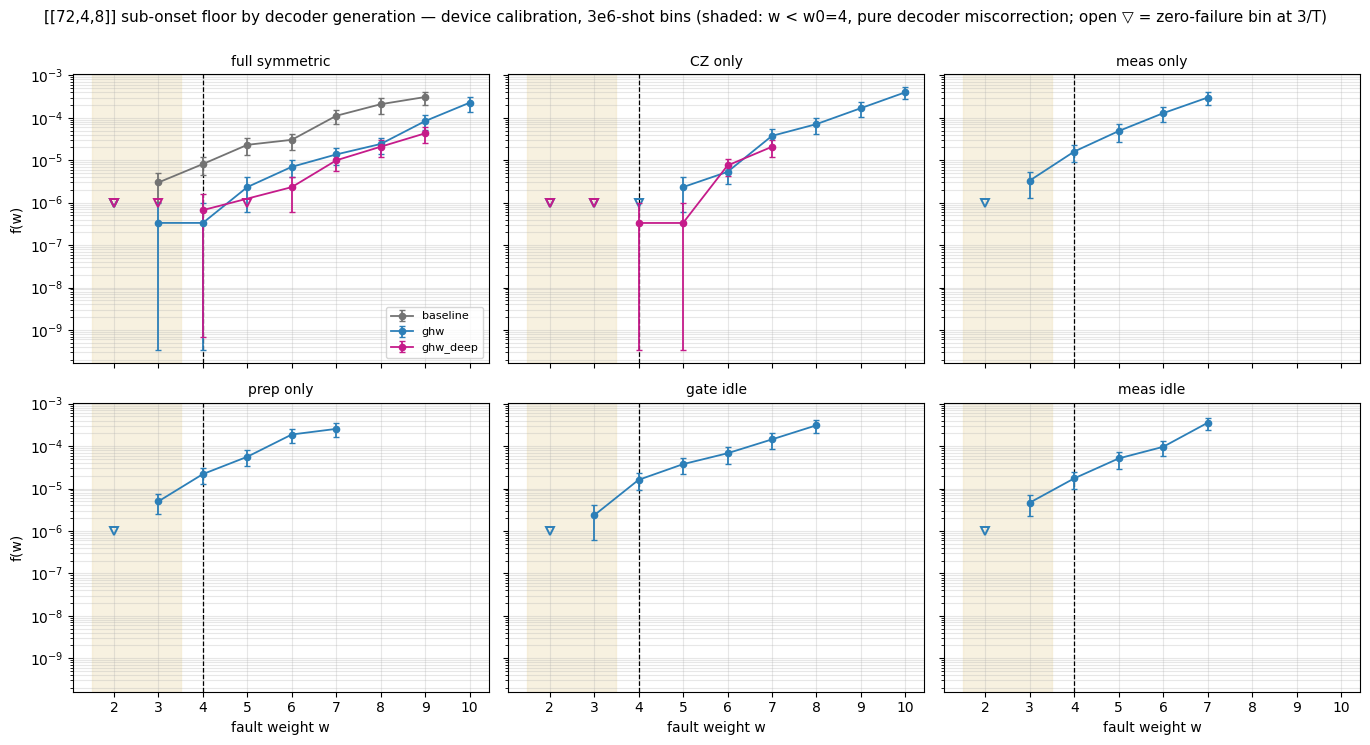

In [2]:
fig_decoder_generations()

## The same numbers, with denominators

Every figure above should be checkable against a count and a shot budget.

In [3]:
decoder_generations_table()


=== baseline ===
model                         w=2               w=3               w=4               w=5
full_symmetric      0/3,000,000       9/3,010,000      20/2,460,000      21/910,000    

=== ghw ===
model                         w=2               w=3               w=4               w=5
full_symmetric      0/3,000,000       1/3,000,000       1/3,000,000       7/3,000,000  
CZ_only             0/3,000,000       0/3,010,000       0/3,010,000       7/3,010,000  
meas_only           0/3,010,000      10/3,010,000      21/1,310,000      20/410,000    
prep_only           0/3,010,000      15/3,010,000      21/960,000        23/410,000    
gate_idle           0/3,000,000       7/3,000,000      20/1,250,000      21/560,000    
meas_idle           0/3,000,000      14/3,010,000      21/1,210,000      21/410,000    

=== ghw_deep ===
model                         w=2               w=3               w=4               w=5
full_symmetric      0/3,000,000       0/3,000,000       2/3,000,000    

## The full IS spectrum, and what it costs in LER

The panels above zoom into the sub-onset band. This is the whole measured spectrum for
the full-symmetric model, plus the reweighted logical error rate it implies — the
quantity the campaign actually quotes. The sub-onset bins are a handful of events out of
millions of shots, but they carry disproportionate weight at low p, because weight-3
faults are vastly more likely than weight-8 ones.

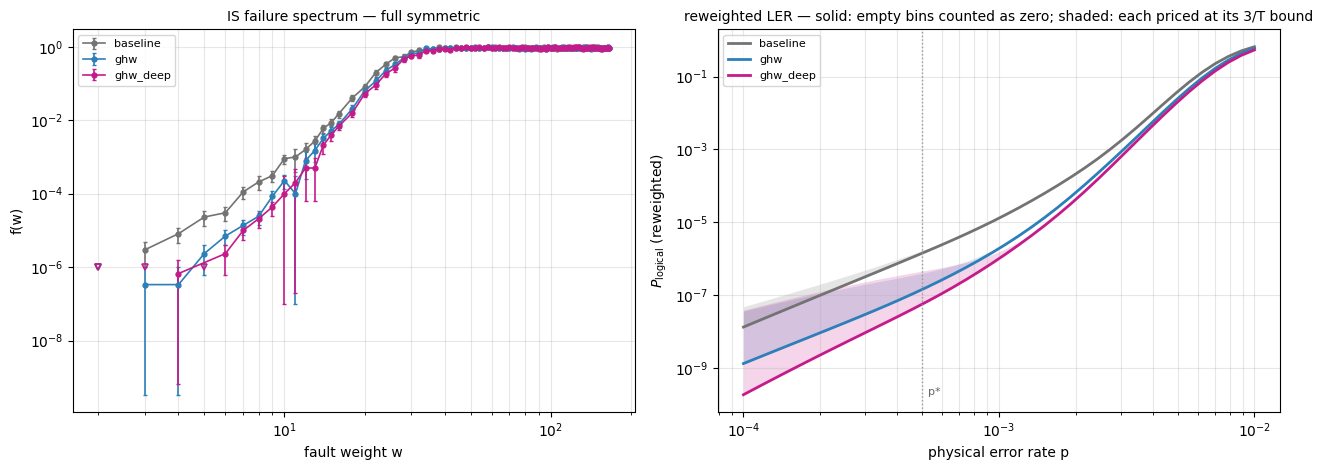

In [4]:
fig_generations_spectra("full_symmetric")

## Λ, by decoder generation

Λ = ε₁₈ / ε₇₂ per round at p*. The [[18,4,4]] code runs the **baseline** decoder in every
campaign — ghw's wide gamma interval is measured-broken there — so Λ moves only through
the 72-code, and the improvement shown is the decoder's alone.

Λ is reported as a range. Zero-failure bins are consistent with any rate below their
rule-of-three bound, so pricing them all at that bound gives the floor; the truth lies
between.

In [5]:
generations_lambda()

Λ = ε18 / ε72  at p* = 0.0005   (18-code = baseline decoder throughout; 2 rounds on the 18-code, 4 on the 72-code)
  ε18 = 2.746e-04

72-code decoder          ε72          Λ    Λ floor   (floor prices every zero bin at 3/T)
baseline          3.520e-07        780        661
ghw               3.553e-08       7728       2774
ghw_deep          1.402e-08      19587       2414

Λ is a RANGE, not a point: unmeasured (zero-failure) low-weight bins could each sit
anywhere below their 3/T bound, and the floor column prices them all at that bound.


## Which fault weights actually carry the LER

$\mathrm{LER}(p) = \sum_w P(W{=}w \mid p)\, f(w)$, so every weight contributes the
product of how likely it is and how often it defeats the decoder. As $p$ falls the
binomial mass collapses toward low weights, and the LER ends up dominated by the
*lightest weight the decoder actually fails* — which is the decoder's property, not the
code's.

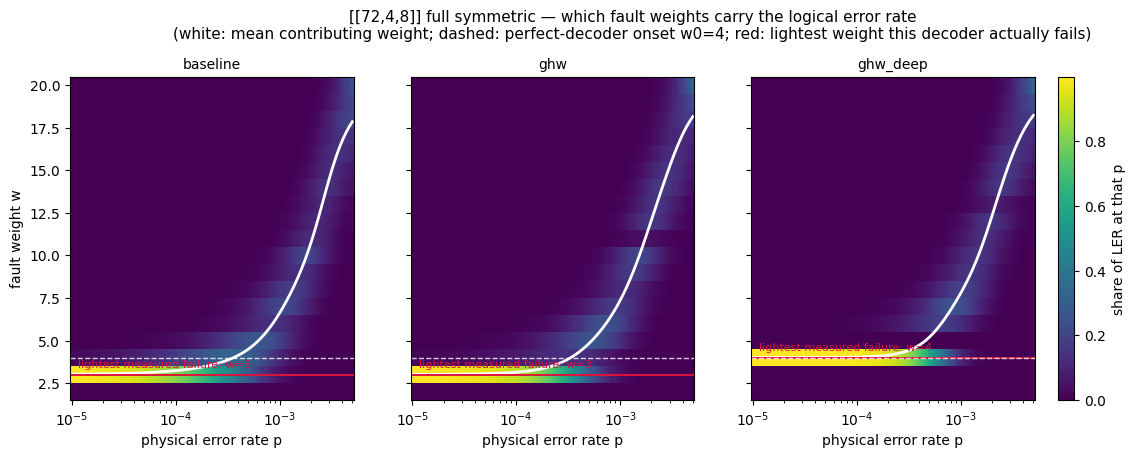

In [6]:
fig_weight_contributions("full_symmetric")

### The consequence: a sub-onset floor changes the exponent

If the lightest failing weight is $w_{\min}$, then $\mathrm{LER} \sim p^{w_{\min}}$
asymptotically. So the floor is not a constant offset — it *degrades the scaling*, and
the penalty grows without bound as $p$ decreases.

In [7]:
ler_slope_table()

decoder     1e-05-1e-04   1e-04-5e-04   2e-04-1e-03   1e-03-5e-03   lightest failing w
baseline           2.97          2.90          3.01          4.97   w = 3
ghw                2.93          2.89          3.28          5.94   w = 3
ghw_deep           3.89          3.54          3.74          6.21   w = 4

The leftmost column is closest to asymptotic. A decoder failing at w=3 scales
as p^3; one clean to the true onset recovers p^4 — the code's own scaling.


## Reading it

* **w = 2 is clean everywhere** — zero failures across millions of shots for every
  decoder and every channel. Two faults never defeat these decoders.
* **The floor is channel-specific.** Under `ghw`, CZ-only contributes nothing at w = 3
  while prep, meas-idle and meas dominate — an attribution that only exists because the
  channels were measured separately at depth.
* **The floor shrinks by generation.** On full symmetric the w = 3 bin goes
  9 → 1 → 0 failures per three million shots.
* **w = 4 is not a defect.** It is exactly $D/2$, where the true fault and its
  complement have equal weight: even a perfect decoder fails a finite fraction there,
  so small differences between decoders at w = 4 are ties, not regressions.
* **Bounds are not zeros.** An open triangle means "no failures in T shots", i.e.
  f(w) < 3/T at 95% confidence — consistent with a small non-zero rate.